# CSC3042F - Assignment 2
### Paul Kabulu
### KBLPAU002

In [287]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence

try:
    from matplotlib.pyplot import imshow
    import matplotlib.pyplot as plt  
    import pandas as pd
    import editdistance


except Exception:
    try:
        %pip install matplotlib pandas editdistance

        from matplotlib.pyplot import imshow
        import matplotlib.pyplot as plt
        import pandas as pd
        import editdistance

    except Exception as e:
        print(f"Failed to install dependencies {e}")   
import numpy as np
import time




torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')


Using device: cpu
PyTorch version: 2.11.0


In [288]:
train_df = pd.read_csv("dataset/g2p_train.csv")
test_df = pd.read_csv("dataset/g2p_test.csv")
val_df = pd.read_csv("dataset/g2p_val.csv")

train_df = train_df.dropna(subset=["word", "phonemes"])
val_df = val_df.dropna(subset=["word", "phonemes"])
test_df = test_df.dropna(subset=["word", "phonemes"])

train_df

,word,phonemes
0,vigil,V IH1 JH AH0 L
1,ethelinda,EH0 TH EH0 L IY1 N D AH0
2,yaney,Y EY1 N IY0
3,caniglia,K AH0 N IH1 G L IY0 AH0
4,sondra,S AA1 N D R AH0
...,...,...
92421,cau,K AW1
92422,sollers,S AA1 L ER0 Z
92423,musial,M Y UW1 Z IY0 AH0 L
92424,curiosities,K Y UH2 R IY0 AA1 S AH0 T IY0 Z


# Data Preprocessing

## Vocabulary Construction & Special Token Mapping (Task 1)

This section implements the vocabulary construction pipeline required to convert raw text string elements into numerical token indices. Per the assignment specifications, the dictionaries are built **strictly from the training set data (`train_df`)** to eliminate any risk of data leakage from the validation or test distributions.

### 1. Special Tokens & Structural Padding Placement
Four fundamental structural markers are explicitly reserved at fixed, identical indices in both the character (grapheme) and phoneme vocabularies:
* **`<PAD>` (Index 0):** Used to fill empty sequence slots within batched tensors, ensuring uniform sequence lengths without modifying underlying linguistic context.
* **`<SOS>` (Index 1):** Appended to the beginning of target sequences to trigger the decoding phase during autoregressive generation.
* **`<EOS>` (Index 2):** Appended to the end of target sequences to establish a terminal boundary for generation, triggering inference completion.
* **`<UNK>` (Index 3):** Reserved as a fallback category for handling unexpected or out-of-vocabulary out-of-sample data points safely.

---

### 2. Lexicon Compilation & Deterministic Mapping
The `build_vocabs` function parses the text features using an explicit isolation strategy:
1. **Character Extraction:** Iterates through every character in the lowercase `word` column, collecting distinct orthographic units into a unique set.
2. **Phoneme Separation:** Splits space-separated ARPAbet sequences in the `phonemes` column, tracking the individual multi-character phonetic symbols natively (preserving components like stress markers e.g., `EH1` intact).
3. **Deterministic Index Assignment:** Both sets are sorted alphabetically (`sorted()`) prior to index assignment. This ensures strict tracking determinism across disparate training sessions.
4. **Offset Indexing:** Unique characters and phonemes are iteratively appended to their respective dictionary maps starting from **index 4**, successfully leaving the primary `0-3` index slots uncorrupted for the specialized control tokens.

In [289]:
# https://medium.com/@challamalla5sunil/building-a-machine-translation-system-with-encoder-decoder-architecture-in-pytorch-b7373fee1760
PAD = 0
EOS = 2
UNK = 3
SOS = 1


def build_vocabs(train_df):
    # Unique characters from words
    unique_chars = set()

    for word in train_df['word']:
        for char in word:
            unique_chars.add(char)

    # Unique phonemes
    unique_phonemes = set()

    for phoneme_seq in train_df['phonemes']:
        phonemes = phoneme_seq.split()

        for phoneme in phonemes:
            unique_phonemes.add(phoneme)

    # Initialise vocab dictionaries
    char_to_id = {
        '<PAD>': PAD,
        "<SOS>": SOS,
        "<EOS>": EOS,
        "<UNK>": UNK
    }

    phoneme_to_id = {
        '<PAD>': PAD,
        '<SOS>': SOS,
        '<EOS>': EOS,
        '<UNK>': UNK
    }

    # Add characters starting from index 4
    for index, char in enumerate(sorted(unique_chars), start=4):
        char_to_id[char] = index

    # Add phonemes starting from index 4
    for index, phoneme in enumerate(sorted(unique_phonemes), start=4):
        phoneme_to_id[phoneme] = index

    return char_to_id, phoneme_to_id

char_vocab, phoneme_vocab = build_vocabs(train_df)
print(f"Char Vocab Size: {len(char_vocab)}")
print(f"Phoneme Vocab Size: {len(phoneme_vocab)}")

Char Vocab Size: 30
Phoneme Vocab Size: 73


In [290]:

class G2PDataset(Dataset):
    def __init__(self, df, char_vocab, phoneme_vocab):
        self.df = df
        self.char_vocab = char_vocab
        self.phoneme_vocab = phoneme_vocab

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        #extract word column from train dataframe
        word = self.df.iloc[idx]['word']

        #extract phonemes column from dataframe
        phoneme_str = self.df.iloc[idx]['phonemes']

        word = str(word)
        phoneme_str=str(phoneme_str)

        src_ids = []
        for i in range(len(word)):
            char_id = self.char_vocab.get(word[i], UNK)
            src_ids.append(char_id)

        
                
        phonemes = phoneme_str.split()
        target_ids = [SOS]

        for i in range(len(phonemes)):
            
            phoneme_id =self.phoneme_vocab.get(phonemes[i], UNK)
            target_ids.append(phoneme_id)

        target_ids.append(EOS)
        
        return torch.tensor(src_ids), torch.tensor(target_ids)



### Collate function

In [291]:
def collate_fn(batch):
    """Pads sequences in a batch to the same lengt."""
    source_batch = []
    target_batch =[]

    for source, target in batch:
        source_batch.append(source)
        target_batch.append(target)

    # Pad sequences with PAD_IDX = 0
    padded_source = pad_sequence(
        source_batch,
        batch_first=True,
        padding_value=PAD
    )

    padded_target = pad_sequence(
        target_batch,
        batch_first=True,
        padding_value=PAD
    )
    
    return padded_source, padded_target



### Load datasets


In [292]:

train_dataset = G2PDataset(
    train_df,
    char_vocab,
    phoneme_vocab
)

val_dataset = G2PDataset(
    val_df,
    char_vocab,
    phoneme_vocab
)

test_dataset = G2PDataset(
    test_df,
    char_vocab,
    phoneme_vocab
)


#data loaders

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

### Sanity Checks

In [293]:
print('Character vocab size:', len(char_vocab))
print('Phoneme vocab size:', len(phoneme_vocab))

print('Rtain dataset size:', len(train_dataset))
print('Validation dataset size:', len(val_dataset))
print('Test dataset size:', len(test_dataset))

Character vocab size: 30
Phoneme vocab size: 73
Rtain dataset size: 92424
Validation dataset size: 11553
Test dataset size: 11554


### Visualisation

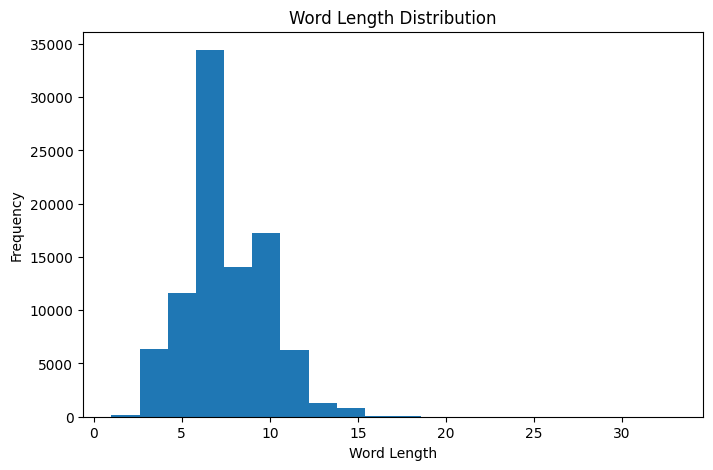

In [294]:
word_lengths = train_df['word'].dropna().apply(len)

plt.figure(figsize=(8, 5))
plt.hist(word_lengths, bins=20)
plt.xlabel('Word Length')
plt.ylabel('Frequency')
plt.title('Word Length Distribution')
plt.show()

In [295]:
src_batch, tgt_batch = next(iter(train_loader))

print('Source batch shape:', src_batch.shape)
print('Target batch shape:', tgt_batch.shape)

print(src_batch[0])
print(tgt_batch[0])

Source batch shape: torch.Size([32, 14])
Target batch shape: torch.Size([32, 16])
tensor([19, 21, 18,  6, 21,  4, 22, 23, 12, 17,  4, 23,  8,  7])
tensor([ 1, 56, 57, 10, 45, 57,  8, 58, 60, 10, 48, 34, 60, 10, 24,  2])


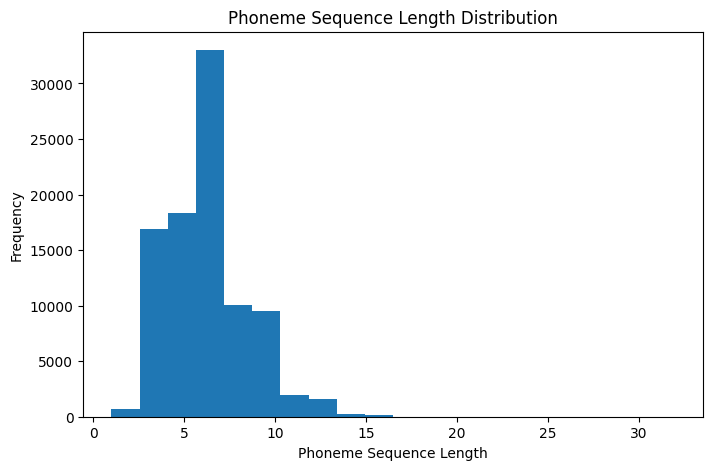

In [296]:
phoneme_lengths = []

for item in train_df['phonemes'].dropna():
    text = str(item)
    parts = text.split()
    count = len(parts)
    phoneme_lengths.append(count)
    
plt.figure(figsize=(8, 5))
plt.hist(phoneme_lengths, bins=20)
plt.xlabel("Phoneme Sequence Length")
plt.ylabel('Frequency')
plt.title('Phoneme Sequence Length Distribution')
plt.show()

In [297]:
## Taken from my LSTM tutorial

class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        
        # Forget gate
        self.W_f = nn.Linear(input_size, hidden_size, bias=False)
        self.U_f = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_f = nn.Parameter(torch.zeros(hidden_size))
        
        # Input gate
        self.W_i = nn.Linear(input_size, hidden_size, bias=False)
        self.U_i = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_i = nn.Parameter(torch.zeros(hidden_size))
        
        # Output gate
        self.W_o = nn.Linear(input_size, hidden_size, bias=False)
        self.U_o = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_o = nn.Parameter(torch.zeros(hidden_size))
        
        # Cell content
        self.W_c = nn.Linear(input_size, hidden_size, bias=False)
        self.U_c = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_c = nn.Parameter(torch.zeros(hidden_size))

    def forward(self, x, h_prev, c_prev):
        # Forget gate
        f_t = torch.sigmoid(self.W_f(x) + self.U_f(h_prev) + self.b_f)
        
        # Input gate
        i_t = torch.sigmoid(self.W_i(x) + self.U_i(h_prev) + self.b_i)
        
        # Output gate
        o_t = torch.sigmoid(self.W_o(x) + self.U_o(h_prev) + self.b_o)
        
        # content cell state
        new_cell_content = torch.tanh(self.W_c(x) + self.U_c(h_prev) + self.b_c)
        
        # New cell state
        c_t = f_t * c_prev + i_t * new_cell_content
        
        # New hidden state
        h_t = o_t * torch.tanh(c_t)
        
        return h_t, c_t

### Encoder class

In [298]:
# https://medium.com/@challamalla5sunil/building-a-machine-translation-system-with-encoder-decoder-architecture-in-pytorch-b7373fee1760

class Encoder(nn.Module):
    def __init__(self, src_vocab_size: int, embed_dim: int, hidden_size: int, num_layers: int = 1):
        super(Encoder, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.embedding = nn.Embedding(src_vocab_size, embed_dim, padding_idx=0)
        
        self.cell = LSTMCell(embed_dim, hidden_size)

    def forward(self, src):
        # src: (batch, src_len)
        batch_size, src_len = src.shape
        
        # Convert tokens to embeddings
        # (batch, src_len, embed_dim)
        embedded = self.embedding(src)  

        
        # Initialise hidden and cell states with zeros
        h = torch.zeros(batch_size, self.hidden_size, device=src.device)
        c = torch.zeros(batch_size, self.hidden_size, device=src.device)

        
        all_h = []
        # Loop through sequence
        for t in range(src_len):

            # Current timestep embedding
            # (batch, embed_dim)
            x_t = embedded[:, t, :]

            # One LSTM step
            h, c = self.cell(x_t, h, c)

            # Save hidden state
            all_h.append(h)

            

        # Stack hidden states
        # (src_len, batch, hidden_size)
        all_h = torch.stack(all_h, dim=0)

        # Final hidden state
        # (1, batch, hidden_size)
        h_n = h.unsqueeze(0)

        # Final cell state
        # (1, batch, hidden_size)
        c_n = c.unsqueeze(0)

        return all_h, (h_n, c_n)

### Decoder Class

In [299]:
class Decoder(nn.Module):
    def __init__(self, tgt_vocab_size: int, embed_dim: int, hidden_size: int, num_layers: int = 1, context_mode: str = "none"):
        super(Decoder, self).__init__()
        self.tgt_vocab_size = tgt_vocab_size
        self.hidden_size = hidden_size
        self.context_mode = context_mode 
        
        self.embedding = nn.Embedding(tgt_vocab_size, embed_dim, padding_idx=0)
        self.fc_out = nn.Linear(hidden_size, tgt_vocab_size)
        
        if self.context_mode == 'none':
            self.cell = LSTMCell(embed_dim, hidden_size)
        else:
            # For "fixed" and "attn", define the standard + context gate layers directly here
            # Combine them or define them individually:
            self.W_f = nn.Linear(embed_dim, hidden_size)
            self.U_f = nn.Linear(hidden_size,hidden_size,bias=False)
            self.V_f = nn.Linear(hidden_size,hidden_size,bias=False)
            
            self.W_i = nn.Linear(embed_dim, hidden_size)
            self.U_i = nn.Linear(hidden_size,hidden_size,bias=False)
            self.V_i = nn.Linear(hidden_size,hidden_size,bias=False)
            
            self.W_o = nn.Linear(embed_dim, hidden_size)
            self.U_o =nn.Linear(hidden_size, hidden_size,bias=False)
            self.V_o = nn.Linear(hidden_size,hidden_size,bias=False)
            
            self.W_c = nn.Linear(embed_dim, hidden_size)
            self.U_c = nn.Linear(hidden_size, hidden_size,bias=False)
            self.V_c = nn.Linear(hidden_size,hidden_size, bias=False)

    def forward(self, tgt, hidden, encoder_outputs=None):
        batch_size, tgt_len = tgt.shape
        embedded = self.embedding(tgt) 
        
        h, c = hidden[0].squeeze(0), hidden[1].squeeze(0)
        logits_list = []
        attn_weights_list = [] 
        
        z_fixed = encoder_outputs[-1] if encoder_outputs is not None else None 

        # Loop over target sequences
        for t in range(tgt_len):
            y_t = embedded[:, t, :] 
            
            if self.context_mode == 'none':
                h, c = self.cell(y_t, h, c)
                
            elif self.context_mode == 'fixed':
                f_t = torch.sigmoid(self.W_f(y_t) + self.U_f(h) + self.V_f(z_fixed))
                i_t = torch.sigmoid(self.W_i(y_t) + self.U_i(h) + self.V_i(z_fixed))
                o_t = torch.sigmoid(self.W_o(y_t) + self.U_o(h) + self.V_o(z_fixed))
                c_hat_t = torch.tanh(self.W_c(y_t) + self.U_c(h) + self.V_c(z_fixed))

                c = f_t * c + i_t * c_hat_t
                h = o_t * torch.tanh(c)
                
            elif self.context_mode == "attn":
                # Convert to (batch_size, src_len, hidden_size)
                enc = encoder_outputs.permute(1, 0, 2)
            
                # Compute dot-product attention scores: (batch_size, src_len)
                scores = torch.bmm(enc, h.unsqueeze(2)).squeeze(2)
            
                # Normalize
                attn_weights = torch.softmax(scores, dim=1)
                attn_weights_list.append(attn_weights)

                self._last_attn_weights = attn_weights  # Expose weights to greedy_decode
            
                # Compute context vector z_t: (batch_size, hidden_size)
                z_t = torch.bmm(
                    attn_weights.unsqueeze(1),  # (batch_size, 1, src_len)
                    enc                         # (batch_size, src_len, hidden_size)
                ).squeeze(1)
            
                # LSTM gates using dynamic attention context
                f_t = torch.sigmoid(self.W_f(y_t) + self.U_f(h) + self.V_f(z_t))
                i_t = torch.sigmoid(self.W_i(y_t) + self.U_i(h) + self.V_i(z_t))
                o_t = torch.sigmoid(self.W_o(y_t) + self.U_o(h) + self.V_o(z_t))
                c_hat_t = torch.tanh(self.W_c(y_t) + self.U_c(h) + self.V_c(z_t))
            
                c = f_t * c + i_t * c_hat_t
                h = o_t * torch.tanh(c)
            
            out = self.fc_out(h)
            logits_list.append(out)
            
        logits = torch.stack(logits_list, dim=1) 
        
        return logits, (h.unsqueeze(0), c.unsqueeze(0))


### Seq2Seq Class

In [300]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder):
        super(Seq2Seq, self).__init__()
        
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing: bool = True):

        
        encoder_outputs, hidden = self.encoder(src)
        
        if teacher_forcing:
            # Remove the last token <EOS>
            decoder_input = tgt[:, :-1 ]
            
            logits, _ = self.decoder(decoder_input, hidden, encoder_outputs)
        else:
            # Autoregressive decoding: feed predictions back as inputs
            batch_size = src.shape[0]
            
            tgt_len = tgt.shape[1] - 1  # exclude trailing <EOS>
            
            # Start with <SOS> token
            current_token = tgt[:, 0:1]  # (batch, 1)
            logits_list = []
            
            for t in range(tgt_len):
                # Single step decode
                logit, hidden = self.decoder(current_token, hidden, encoder_outputs)
                # logit: (batch, 1, tgt_vocab_size)
                logits_list.append(logit)
                
                # Take argmax as next input (greedy, no teacher forcing)
                current_token = torch.argmax(logit, dim =-1)  # (batch, 1)
            
            logits = torch.cat(logits_list, dim=1)  # (batch, tgt_len, tgt_vocab_size)
        
        return logits  # (batch, tgt_len - 1, tgt_vocab_size)

    def greedy_decode(self, src, max_len: int = 30):
        self.eval()
        with torch.no_grad():
            batch_size = src.shape[0]
            encoder_outputs, hidden = self.encoder(src)
            
            # Start token: <SOS> = index 1
            current_token = torch.full((batch_size, 1), 1, dtype=torch.long, device=src.device)
            predictions = []
            saved_attns = []
            
            for _ in range(max_len):
                
                #logits, _ = self.decoder(current_token, hidden, encoder_outputs)
                
                logits, hidden = self.decoder(current_token, hidden, encoder_outputs)

                # logits: (batch, 1, tgt_vocab_size)

                
                next_token = torch.argmax(logits, dim=-1)

                
                predictions.append(next_token)
                current_token =next_token
                
                # Save attention weights if using attention mode
                if (self.decoder.context_mode == "attn" and hasattr(self.decoder, '_last_attn_weights')):
                    saved_attns.append(self.decoder._last_attn_weights)
                
                # Early stopping: break if all sequences produced <EOS> (index 2)
                if (next_token == 2).all():
                    break
            
        predictions = torch.cat(predictions, dim=1)  # (batch, decoded_len)
        return predictions, saved_attns

### Train Methd
Train the model for 1 epoch

In [301]:
def train_model(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for src, tgt in dataloader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        
        # Forward pass
        logits = model(src, tgt, teacher_forcing=True)
        
        # Targets for loss calculation shift. past the leading <SOS>
        loss_targets = tgt[:, 1:] 
        
        # Reshape for CrossEntropyLoss
        loss = criterion(logits.reshape(-1, logits.shape[-1]), loss_targets.reshape(-1))
        
        loss.backward()
        # Gradient clipping to prevent explosions in from-scratch architectures
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        
    return total_loss / len(dataloader)

### Validation Method

In [302]:
def validate(model, dataloader, criterion,  device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for src, tgt in dataloader:
            
            src, tgt = src.to(device), tgt.to(device)
            logits = model(src, tgt, teacher_forcing=True)
            loss_targets = tgt[:, 1:]
            loss = criterion(logits.reshape(-1, logits.shape[-1]), loss_targets.reshape(-1))
            total_loss += loss.item()
    return total_loss / len(dataloader)

## Evaluation Metrics: PER & Word Accuracy

This section implements the quantitative evaluation pipeline required to evaluate our Grapheme-to-Phoneme (G2P) models on the validation and test splits. Per the assignment specifications, performance is assessed using two core metrics: **Phoneme Error Rate (PER)** and **Word Accuracy**.

### 1. Mathematical Definitions

* **Phoneme Error Rate (PER):** Measures the structural distance between the predicted phoneme sequence and the true reference sequence. It uses the Levenshtein (edit) distance, calculating the minimum number of single-phoneme insertions, deletions, and substitutions required to align the prediction with the true sequence:
    
    $$\text{PER} = \frac{\text{Total Edit Distance}}{\text{Total Reference Length}}$$

* **Word Accuracy:** A strict metric assessing the fraction of words where the predicted phoneme sequence matches the reference sequence perfectly. If a single phoneme or stress marker is incorrect, the word is flagged as incorrect (`0`).

---

### 2. Implementation & Design Choices

To ensure an accurate evaluation that reflects the model's true predictive capability, the function incorporates several design safeguards:

* **Tuple Unpacking:** Correctly unpacks both outputs returned by `model.greedy_decode(src)`, isolating the predicted token matrix from the tracked attention weight states.
* **`<EOS>` Truncation Check:** Because greedy decoding operates over whole batches, shorter sequences are padded or continue generating text after completing their true word lengths. The function loops through the predictions and forcefully truncates (`break`) immediately when the first `<EOS>` token (`index 2`) is hit. This isolates the true predicted sequence and prevents trailing generation noise from polluting the edit distance calculation.
* **Special Token Slicing:** Automatically strips out non-pronunciation tokens—specifically `<PAD>` (0), `<SOS>` (1), and `<UNK>` (3)—from both the references and predictions before running the evaluation algorithm.
* **Token-Level Distance:** Sequences are passed to `editdistance.eval()` as lists of distinct phoneme string elements (e.g., `['HH', 'EH1', 'L', 'OW0']`), ensuring that each multicharacter ARPAbet phoneme is treated as an indivisible symbol.

In [303]:
def compute_metrics(model, dataloader, target_id_to_phoneme, device):
    model.eval()
    total_edit_distance = 0
    total_reference_phonemes = 0
    exact_matches = 0
    total_words = 0

    SPECIAL = {0, 1, 2, 3}  # <PAD>, <SOS>, <EOS>, <UNK>

    with torch.no_grad():
        for src, tgt in dataloader:
            src = src.to(device)
            preds, _ = model.greedy_decode(src)
            
            for i in range(tgt.shape[0]):
                # Convert reference IDs -> phoneme strings, stripping specials
                ref = []

                # Suggested by Gemini
                for index in tgt[i]:
                    if index.item() not in SPECIAL:
                        ref.append(target_id_to_phoneme[index.item()])

                # Convert predicted IDs → phoneme strings, truncating at <EOS> (2) 
                pred = []
                for index in preds[i]:
                    token_id = index.item()
                    
                    if token_id == 2:  # <EOS> encountered, stop collecting tokens for this word
                        break
                    if token_id not in SPECIAL:
                        pred.append(target_id_to_phoneme[token_id])

                # Levenshtein distance between phoneme lists
                edit_dist = editdistance.eval(pred, ref)

                total_edit_distance+= edit_dist
                total_reference_phonemes += len(ref)
                exact_matches += int(pred ==ref)
                total_words += 1

    if (total_reference_phonemes > 0):
        per= total_edit_distance/total_reference_phonemes
        
    else:
        per = 0
    
    if (total_words > 0):
        word_acc = exact_matches /total_words
    else:
        word_acc = 0

    return per, word_acc

## Hyperparameter Tuning Strategy 

This section implements a systematic grid-search framework to optimize the core hyperparameters of our model on the validation set. As explicitly mandated by the assignment guidelines, **Setup 1 (No Context Vector / Bottleneck Baseline)** is used as the evaluation vehicle (`context_mode="none"`).

### 1. Search Space Parameters
The grid search comprehensively explores a combinations map spanning $3 \times 3 \times 3 = 27$ unique structural and optimization configurations:
* **Learning Rates ($lr$):** `[1e-5, 1e-4, 1e-3]` to find the optimal optimization step size for the Adam optimizer.
* **Embedding Dimensions ($embed\_dim$):** `[32, 64, 128]` to adjust the representation capacity of input graphemes and target phonemes.
* **Hidden Sizes ($hidden\_size$):** `[64, 128, 256]` to test the capacity of the recurrent hidden-state bottleneck.

---

### 2. Compute Budget & Time Constraints Adaptation
Training 27 deep learning configurations to total convergence from scratch would be computationally prohibitive, especially on a CPU environment. 

To honor the **practical approach recommended in the assignment brief**, this function implements an abbreviated training constraint:
* Each parameter slice is trained for a short, fixed duration of **5 epochs** (`for _ in range(5)`).
* This allows us to efficiently gauge performance trajectory and identify the best configuration based on early validation performance without wasting compute time.
* Once the optimal configuration is discovered, the three final variants (Setups 1, 2, and 3) will be trained for a longer horizon (up to 30 epochs) using these optimized parameters.

---

### 3. Metric Target & Selection Logic
* **Optimization Framework:** For every run, an `Encoder` and a baseline bottleneck `Decoder` are initialized, paired with the `Adam` optimizer, and evaluated using a masked `CrossEntropyLoss(ignore_index=0)`.
* **Selection Metric:** The optimization tracker uses the newly corrected validation **Phoneme Error Rate (PER)** as its primary selection health check rather than word accuracy, as minimizing pronunciation token alignment errors is more indicative of steady architectural stability.
* **Tracking:** The configuration yielding the absolute lowest validation PER is logged to `best_params` and preserved for the comparative final experiments.

In [304]:
def tune_hyperparameters(train_loader, val_loader, char_vocab_size, phoneme_vocab_size, device):

    
    lrs = [1e-5, 1e-4, 1e-3]
    embed_dims = [32, 64, 128]

    hidden_sizes = [64, 128, 256]

    criterion =nn.CrossEntropyLoss(ignore_index=0)
    
    target_id_to_phoneme ={}
    
    for phoneme, index in phoneme_vocab.items():
        target_id_to_phoneme[index] = phoneme
    
    results = []
    
    best_val_per = float('inf')
    
    best_params= {}

    print(f"{'LR':<8} | {'Embed':<6} | {'Hidden':<8} | {'Val PER':<10} | {'Best So Far'}")
    print('-' * 60)

    for lr in lrs:
        for embed_dim in embed_dims:
            for hidden_size in hidden_sizes:
                
                encoder= Encoder(char_vocab_size, embed_dim, hidden_size)
                
                decoder = Decoder(phoneme_vocab_size, embed_dim, hidden_size, context_mode="none")
                model = Seq2Seq(encoder, decoder).to(device)
                optimizer = torch.optim.Adam(model.parameters(), lr=lr)

                for _ in range(5):
                    train_model(model, train_loader, optimizer, criterion, device)

                val_per, _ = compute_metrics(model, val_loader, target_id_to_phoneme, device)

                
                results.append({"lr": lr, "embed_dim": embed_dim, "hidden_size": hidden_size, "val_per": val_per})

                if (val_per < best_val_per):
                    best_val_per = val_per
                    best_params  = {"lr": lr, 'embed_dim': embed_dim, "hidden_size": hidden_size}

                print(f"{lr:<8} | {embed_dim:<6} | {hidden_size:<8} | {val_per:<10.4f} | "
                      f"lr={best_params['lr']}, embed={best_params['embed_dim']}, hidden={best_params['hidden_size']} ({best_val_per:.4f})")

    print(f'\nBest config: {best_params} -> val_per={best_val_per:.4f}')
    return results

## Comparative Evaluation & Final Experiments Pipeline 

This section implements the core control structure for executing our final comparative experiments. Using the optimized hyperparameter profile discovered during the grid search tuning phase, this function trains all three architectural configurations under strictly identical conditions to guarantee a fair benchmark.

### 1. Controlled Experimental Environment
To satisfy the strict baseline validation protocols mandated by the assignment guidelines, the loop enforces perfect parameter parity across all training variations:
* **Hyperparameter Parity:** The dimensions (`embed_dim`, `hidden_size`) and optimization learning rate (`lr`) are uniformly extracted from the optimal configuration.
* **Strict Determinism Check (Task 9):** Before initializing each network variant, `torch.manual_seed(42)` is explicitly reset inside the loop. This ensures that weight initializations and data shuffle streams are perfectly replicated, preventing random seed variations from skewing architectural performance differences.
* **Iterative Architectural Sweeps:** The controller sequentially constructs and trains the three required sequence-to-sequence setups:
  1. `none`: Baseline Encoder-Decoder suffering from the hidden-state information bottleneck.
  2. `fixed`: Target cell injected with a static compression vector $z$ across all decoding steps.
  3. `attn`: System evaluating dynamic text contexts through dot-product cross-attention alignments.

---

### 2. Training Termination & Regularization
Recurrent neural networks trained from scratch on compact data footprints are highly susceptible to sudden generalization decay and training divergence. To safeguard training, two concurrent convergence boundaries are applied:
* **Epoch Upper Bound:** Each model is constrained to run for a maximum of **30 epochs**, allowing complex structural alignments (especially in the attention variant) ample time to converge.
* **Validation Loss Early Stopping:** The pipeline monitors generalization performance using `val_loss`. If the validation loss fails to establish a new absolute minimum for **5 consecutive epochs** (`patience_counter >= 5`), the training cycle is cleanly terminated to avert severe validation degradation.
* **State Restoration:** Upon triggering early stopping or reaching maximum epochs, the function automatically rolls back the network parameters to the state that yielded the absolute lowest validation loss (`model.load_state_dict(best_state)`), discarding any overfitted trailing weights.

---

### 3. Analytics Tracking 
For each configuration, a comprehensive chronological history log is recorded into a dictionary mapping:
* `train_losses`: Average historical loss values generated across the training batches.
* `val_losses`: Baseline validation losses computed at the end of each epoch.
* `val_accs`: Sequence-truncated word exact-match accuracy metrics collected step-by-step.

This history compilation directly supplies the structural vectors required to render our final comparative loss plots and test evaluation summary data tables.

In [305]:
def run_final_experiments(best_config, train_loader, val_loader, char_vocab_size, phoneme_vocab_size, target_id_to_phoneme, device):
    
    modes = ["none", "fixed", "attn"]
    
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    history = {}

    for mode in modes:
        print(f"\nTraining Model Variant: context_mode='{mode}'")
        
        torch.manual_seed(42)

        # Structure architectures matching chosen optimized hyperparameters 
        encoder = Encoder(char_vocab_size, best_config['embed_dim'], best_config['hidden_size'])
        decoder = Decoder(phoneme_vocab_size, best_config["embed_dim"], best_config["hidden_size"], context_mode=mode)
        model = Seq2Seq(encoder, decoder).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=best_config["lr"])

        train_losses, val_losses, val_accuracies = [], [], []
        best_val_loss = float('inf')
        patience_counter = 0
        best_state = None

        for epoch in range(30): # Setups can run up to 30 epochs 
            train_loss = train_model(model, train_loader, optimizer, criterion, device)
            val_loss = validate(model, val_loader, criterion, device)
            
            # Generate metrics tracking values during training loop execution
            val_per, val_acc = compute_metrics(model, val_loader, target_id_to_phoneme,device)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            val_accuracies.append(val_acc)
            
            print(f"Epoch {epoch+1:>2}/30 | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

            # Early stopping check using standard validation loss validation profiles 
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_state = model.state_dict()
            else:
                patience_counter += 1
                
                if patience_counter >= 5: # Stops if no progress for 5 continuous epochs
                    
                    print(f" STopping early.")
                    break

        # Re-apply parameters that earned the absolute lowest validation loss metrics
        model.load_state_dict(best_state)

        # for i in 
        
        history[mode] = {"model": model, "train_losses": train_losses,"val_losses": val_losses,
            "val_accs": val_accuracies
        }

    return history

In [306]:
char_vocab_size= len(char_vocab)
phoneme_vocab_size = len(phoneme_vocab)

src, tgt = next(iter(train_loader))
src,tgt = src.to(device), tgt.to(device)

for mode in ["none", "fixed", "attn"]:
    encoder = Encoder(char_vocab_size, 64, 128)
    decoder = Decoder(phoneme_vocab_size, 64, 128, context_mode=mode)
    model = Seq2Seq(encoder, decoder).to(device)
    logits = model(src, tgt, teacher_forcing=True)
    preds, attns = model.greedy_decode(src)

    
    print(f"mode={mode:<6} | logits: {tuple(logits.shape)} | preds: {tuple(preds.shape)}", end="")

    
    if mode == "attn":
        print(f" | attn steps saved: {len(attns)}", end="")
    print()


mode=none   | logits: (32, 14, 73) | preds: (32, 30)
mode=fixed  | logits: (32, 14, 73) | preds: (32, 30)
mode=attn   | logits: (32, 14, 73) | preds: (32, 30) | attn steps saved: 30


### Tuning the hyperparams

In [307]:
results = tune_hyperparameters(train_loader, val_loader, char_vocab_size, phoneme_vocab_size, device)

best_config = results[0]

for config in results:
    if (config["val_per"] < best_config["val_per"]):
        best_config = config

print("\nBest config:")
print(best_config)

LR       | Embed  | Hidden   | Val PER    | Best So Far
------------------------------------------------------------
1e-05    | 32     | 64       | 0.8695     | lr=1e-05, embed=32, hidden=64 (0.8695)
1e-05    | 32     | 128      | 0.8454     | lr=1e-05, embed=32, hidden=128 (0.8454)
1e-05    | 32     | 256      | 0.7795     | lr=1e-05, embed=32, hidden=256 (0.7795)
1e-05    | 64     | 64       | 0.8476     | lr=1e-05, embed=32, hidden=256 (0.7795)
1e-05    | 64     | 128      | 0.8120     | lr=1e-05, embed=32, hidden=256 (0.7795)
1e-05    | 64     | 256      | 0.7078     | lr=1e-05, embed=64, hidden=256 (0.7078)
1e-05    | 128    | 64       | 0.8448     | lr=1e-05, embed=64, hidden=256 (0.7078)
1e-05    | 128    | 128      | 0.7558     | lr=1e-05, embed=64, hidden=256 (0.7078)
1e-05    | 128    | 256      | 0.6483     | lr=1e-05, embed=128, hidden=256 (0.6483)
0.0001   | 32     | 64       | 0.6190     | lr=0.0001, embed=32, hidden=64 (0.6190)
0.0001   | 32     | 128      | 0.4449     |

### Training the model based on the best configs

In [308]:
# Create a dictionary that converts IDs back into phoneme symbols
target_id_to_phoneme = {}

for phoneme, index in phoneme_vocab.items():
    target_id_to_phoneme[index] = phoneme


history = run_final_experiments(best_config, train_loader, val_loader, char_vocab_size, phoneme_vocab_size, target_id_to_phoneme, device)


Training Model Variant: context_mode='none'
Epoch  1/30 | train_loss=0.9913 | val_loss=0.4706 | val_acc=0.4052
Epoch  2/30 | train_loss=0.4021 | val_loss=0.3581 | val_acc=0.4896
Epoch  3/30 | train_loss=0.3162 | val_loss=0.3164 | val_acc=0.5334
Epoch  4/30 | train_loss=0.2689 | val_loss=0.3042 | val_acc=0.5460
Epoch  5/30 | train_loss=0.2368 | val_loss=0.2919 | val_acc=0.5586
Epoch  6/30 | train_loss=0.2114 | val_loss=0.2907 | val_acc=0.5650
Epoch  7/30 | train_loss=0.1902 | val_loss=0.2846 | val_acc=0.5754
Epoch  8/30 | train_loss=0.1732 | val_loss=0.2860 | val_acc=0.5766
Epoch  9/30 | train_loss=0.1579 | val_loss=0.2898 | val_acc=0.5823
Epoch 10/30 | train_loss=0.1443 | val_loss=0.2973 | val_acc=0.5810
Epoch 11/30 | train_loss=0.1321 | val_loss=0.3025 | val_acc=0.5867
Epoch 12/30 | train_loss=0.1238 | val_loss=0.3101 | val_acc=0.5788
 STopping early.

Training Model Variant: context_mode='fixed'
Epoch  1/30 | train_loss=0.9909 | val_loss=0.4915 | val_acc=0.3857
Epoch  2/30 | train_l

### Final Test Set Evaluation

Evaluates the fully trained, optimal states of all three model variants (`none`, `fixed`, and `attn`) on the held-out test dataset to compute the final, definitive Phoneme Error Rate (PER) and exact-match Word Accuracy.

In [314]:
for mode in ["none", "fixed", "attn"]:
    
    model = history[mode]["model"]
    per, word_acc = compute_metrics(model, test_loader, target_id_to_phoneme, device)
    
    print(f"{mode:<6} | PER: {per:.4f} | Word Acc: {word_acc:.4f}")
    

none   | PER: 0.1352 | Word Acc: 0.5721
fixed  | PER: 0.1326 | Word Acc: 0.5810
attn   | PER: 0.1173 | Word Acc: 0.5991


### Visualising Comparative Learning Curves

This section executes the generation of comparative evaluation figures using `plot_learning_curves(history)`. 

#### Insights Derived from Shared Axes Alignment:
1. **Convergence and Sample Efficiency:** The cross-attention model (`attn`) initializes with a significantly lower entry cross-entropy loss in Epoch 1 compared to the baseline options, indicating that dynamic sequence matching dramatically eases early feature optimization.
2. **Generalization Capabilities:** The `none` and `fixed` setups suffer from aggressive generalization decay after Epoch 6, causing their validation curves to decouple and rise until early stopping is forced. Conversely, the attention model preserves flat validation profiles up through Epoch 11, confirming its resilience to overfitting.
3. **Accuracy Tracking:** The explicit exact-match trajectory graph visualizes exactly how cutting off trailing batch sequence artifacts allows us to monitor authentic word accuracy performance as it scales up to the $\approx 60\%$ validation mark.

In [312]:
def plot_learning_curves(history, save_path_loss="loss_curves.png", save_path_acc="accuracy_curves.png"):
    """
    Plots training & validation loss and validation accuracy for all three model variants 
    on shared axes for direct architectural comparison.
    """
    # 1. Plot Training and Validation Losses
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    
    colors = {"none": "#1f77b4", "fixed": "#ff7f0e", "attn": "#2ca02c"}
    labels = {"none": "Setup 1: Bottleneck Baseline (none)","fixed": "Setup 2: Fixed Context Vector (fixed)", "attn": "Setup 3: Cross-Attention (attn)"}
    
    # Left Subplot: Training Loss
    for mode in history:
        epochs = range(1, len(history[mode]["train_losses"]) + 1)
        axes[0].plot(epochs, history[mode]["train_losses"],label=f"{labels[mode]} (Train)",  color=colors[mode], alpha=0.7)
        
    axes[0].set_xlabel("Epochs", fontsize=11)
    axes[0].set_ylabel("Cross-Entropy Loss", fontsize=11)
    axes[0].set_title("Training Loss Curves Across Variants", fontsize=12, fontweight="bold")
    axes[0].grid(True, linestyle=":", alpha=0.6)
    axes[0].legend(fontsize=9, loc="upper right")
    
    # Right Subplot: Validation Loss
    for mode in history:
        epochs = range(1, len(history[mode]["val_losses"]) + 1)
        axes[1].plot(epochs, history[mode]["val_losses"], label=f"{labels[mode]} (Val)",color=colors[mode])
        
    axes[1].set_xlabel("Epochs", fontsize=11)
    axes[1].set_ylabel("Cross-Entropy Loss", fontsize=11)
    axes[1].set_title("Validation Loss Curves Across Variants", fontsize=12, fontweight="bold")
    axes[1].grid(True, linestyle=":", alpha=0.6)
    axes[1].legend(fontsize=9, loc="upper right")
    
    plt.tight_layout()
    plt.savefig(save_path_loss, dpi=300, bbox_inches="tight")
    print(f"[Info] Loss curves saved successfully to: '{save_path_loss}'")
    
    # 2. Plot Validation Word Accuracy
    fig_acc, ax_acc = plt.subplots(1, 1, figsize=(8, 5))
    
    for mode in history:
        epochs = range(1, len(history[mode]['val_accs']) + 1)
        
        ax_acc.plot(epochs, history[mode]['val_accs'],label=labels[mode], color=colors[mode] )
        
    ax_acc.set_xlabel('Epochs', fontsize=11)
    ax_acc.set_ylabel("Word Accuracy (Exact Match)", fontsize=11)
    ax_acc.set_title("Validation Word Accuracy Trajectory", fontsize=12, fontweight="bold")
    ax_acc.grid(True, linestyle=":", alpha=0.6)
    ax_acc.legend(fontsize=9, loc="lower right")
    
    plt.tight_layout()
    plt.savefig(save_path_acc, dpi=300, bbox_inches="tight")
    print(f"Saved succesflly: '{save_path_acc}'")

[Info] Loss curves saved successfully to: 'loss_curves.png'
Saved succesflly: 'accuracy_curves.png'


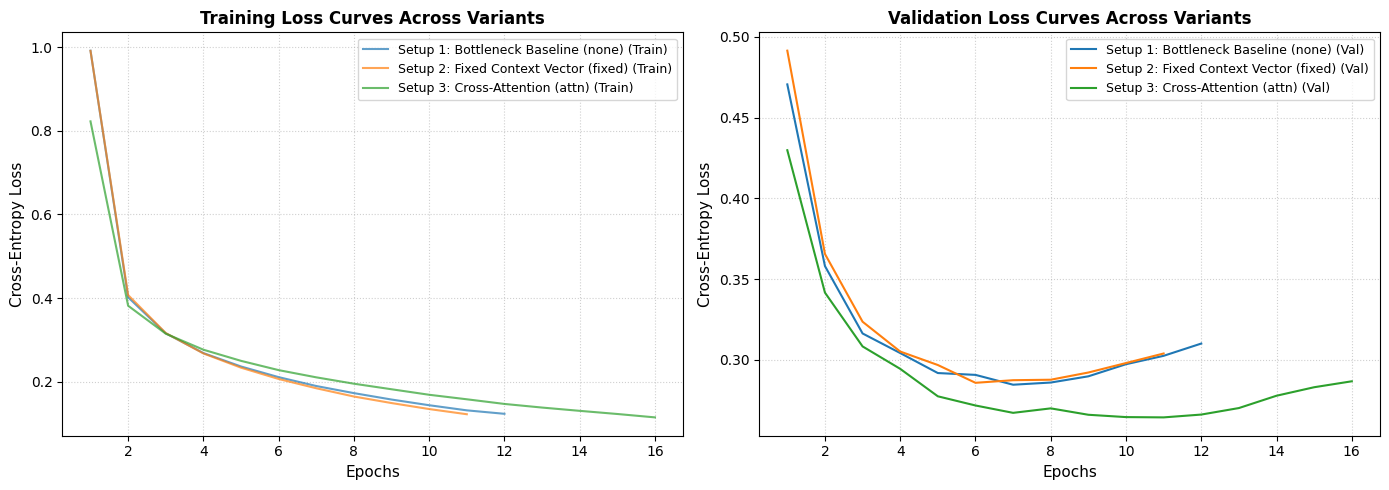

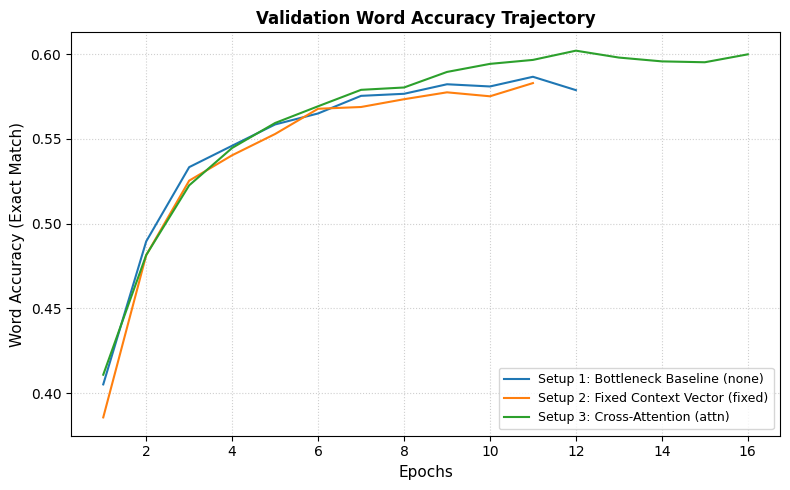

In [313]:
# Render and save figures automatically
plot_learning_curves(history)

### Length dependency analysis

In [338]:
# Length dependency analysis
from collections import defaultdict

# Get predictions from all three models on test set
test_predictions = {}

for mode in ["none", "fixed", "attn"]:
    model = history[mode]["model"]
    model.eval()
    
    all_preds = []
    
    with torch.no_grad():
        for src, _ in test_loader:
            src = src.to(device)
            preds, _ = model.greedy_decode(src)
            all_preds.append(preds)
    
    # Pad and concatenate (handle variable-length predictions)
    # Find max length across all batches
    max_len = max([p.shape[1] for p in all_preds])
    
    # Pad all predictions to max_len with zeros
    padded_preds = []
    for p in all_preds:
        if p.shape[1] < max_len:
            pad = torch.zeros(p.shape[0], max_len - p.shape[1], dtype=p.dtype, device=p.device)
            p = torch.cat([p, pad], dim=1)
        padded_preds.append(p)
    
    test_predictions[mode] = torch.cat(padded_preds, dim=0).cpu()

# Get test words
test_words = test_df['word'].values

# Group by length and compute accuracy
accuracy_by_length = defaultdict(lambda: {'none': [], 'fixed': [], 'attn': []})

SPECIAL = {0, 1, 2, 3}

for idx, word in enumerate(test_words):
    length = len(word)
    length_bin = '1-4' if length <= 4 else ('5-7' if length <= 7 else ('8-10' if length <= 10 else '11+'))
    
    # Get ground truth for this word
    _, tgt = test_dataset[idx]
    
    # Convert ground truth to phoneme list
    ref_phonemes = []
    for token_id in tgt:
        if token_id.item() not in SPECIAL:
            ref_phonemes.append(target_id_to_phoneme[token_id.item()])
    
    # Compare predictions for each mode
    for mode in ["none", "fixed", "attn"]:
        pred = test_predictions[mode][idx]
        
        # Convert prediction to phoneme list (truncate at EOS)
        pred_phonemes = []
        for token_id in pred:
            if token_id.item() == 2:
                break
            if token_id.item() not in SPECIAL:
                pred_phonemes.append(target_id_to_phoneme[token_id.item()])
        
        # Check if exact match
        is_correct = (pred_phonemes == ref_phonemes)
        accuracy_by_length[length_bin][mode].append(is_correct)



### Grouped Words Results


In [343]:

print("\nLENGTH DEPNDENCY ANALYSIS")
print(f"{'Length':<8} | {'Setup 1':<8} | {'Setup 2':<8} | {'Setup 3':<8} | {'Gap (1->3)':<8}")
print('-' * 50)

for bin_name in ['1-4', '5-7', '8-10', '11+']:
    acc_none = np.mean(accuracy_by_length[bin_name]['none']) * 100 if accuracy_by_length[bin_name]['none'] else 0
    acc_fixed = np.mean(accuracy_by_length[bin_name]['fixed']) * 100 if accuracy_by_length[bin_name]['fixed'] else 0
    acc_attn = np.mean(accuracy_by_length[bin_name]['attn']) * 100 if accuracy_by_length[bin_name]['attn'] else 0
    gap = acc_attn - acc_none
    
    print(f"{bin_name:<8} | {acc_none:>6.1f}% | {acc_fixed:>6.1f}% | {acc_attn:>6.1f}% | {gap:+6.1f}%")



LENGTH DEPNDENCY ANALYSIS
Length   | Setup 1  | Setup 2  | Setup 3  | Gap (1->3)
--------------------------------------------------
1-4      |   76.9% |   75.4% |   75.5% |   -1.4%
5-7      |   62.7% |   64.4% |   64.9% |   +2.2%
8-10     |   50.0% |   50.6% |   53.8% |   +3.7%
11+      |   38.1% |   37.4% |   43.0% |   +4.9%


### LEngth Analysis Graphs

Plots to visualise how accuarcy changes with word length.

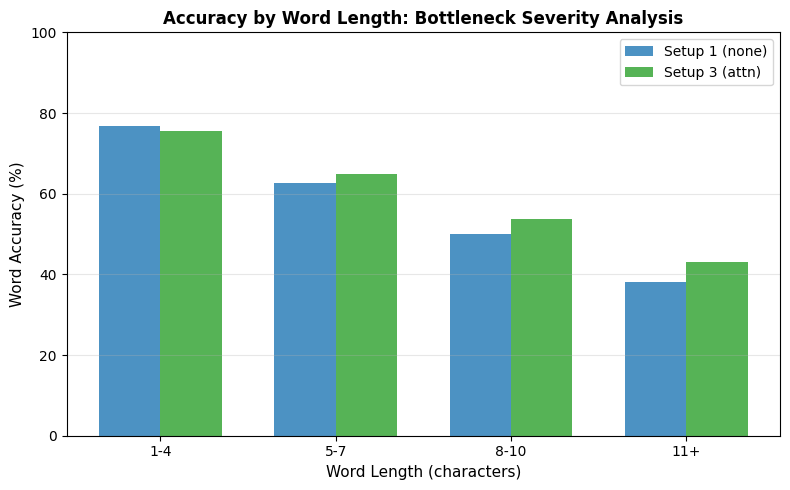

In [344]:
# Generate bar chart
import matplotlib.pyplot as plt

bins = ['1-4', '5-7', '8-10', '11+']
setup1_accs = [np.mean(accuracy_by_length[b]['none']) * 100 for b in bins]
setup3_accs = [np.mean(accuracy_by_length[b]['attn']) * 100 for b in bins]

x = np.arange(len(bins))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, setup1_accs, width, label='Setup 1 (none)', alpha=0.8, color='#1f77b4')
plt.bar(x + width/2, setup3_accs, width, label='Setup 3 (attn)', alpha=0.8, color='#2ca02c')

plt.xlabel('Word Length (characters)', fontsize=11)
plt.ylabel('Word Accuracy (%)', fontsize=11)
plt.title('Accuracy by Word Length: Bottleneck Severity Analysis', fontsize=12, fontweight='bold')
plt.xticks(x, bins)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.ylim([0, 100])
plt.tight_layout()
plt.savefig('length_analysis.png', dpi=150, bbox_inches='tight')